Processing dataset1 - tspcRoundRobin2 with 10 files.
Processing dataset1 - tspcLoadBal2 with 10 files.
Processing dataset1 - tspcKmean2 with 10 files.
Processing dataset1 - tspcRightAsc2 with 10 files.
Processing dataset1 - tspcKMeanEarlySetting2 with 10 files.
Processing dataset1 - tspcRoundRobin3 with 10 files.
Processing dataset1 - tspcLoadBal3 with 10 files.
Processing dataset1 - tspcKmean3 with 10 files.
Processing dataset1 - tspcRightAsc3 with 10 files.
Processing dataset1 - tspcKMeanEarlySetting3 with 10 files.
Processing dataset1 - tspcRoundRobin4 with 10 files.
Processing dataset1 - tspcLoadBal4 with 10 files.
Processing dataset1 - tspcKmean4 with 10 files.
Processing dataset1 - tspcRightAsc4 with 10 files.
Processing dataset1 - tspcKMeanEarlySetting4 with 10 files.
Processing dataset1 - tspcRoundRobin5 with 10 files.
Processing dataset1 - tspcLoadBal5 with 10 files.
Processing dataset1 - tspcKmean5 with 10 files.
Processing dataset1 - tspcRightAsc5 with 10 files.
Processing d

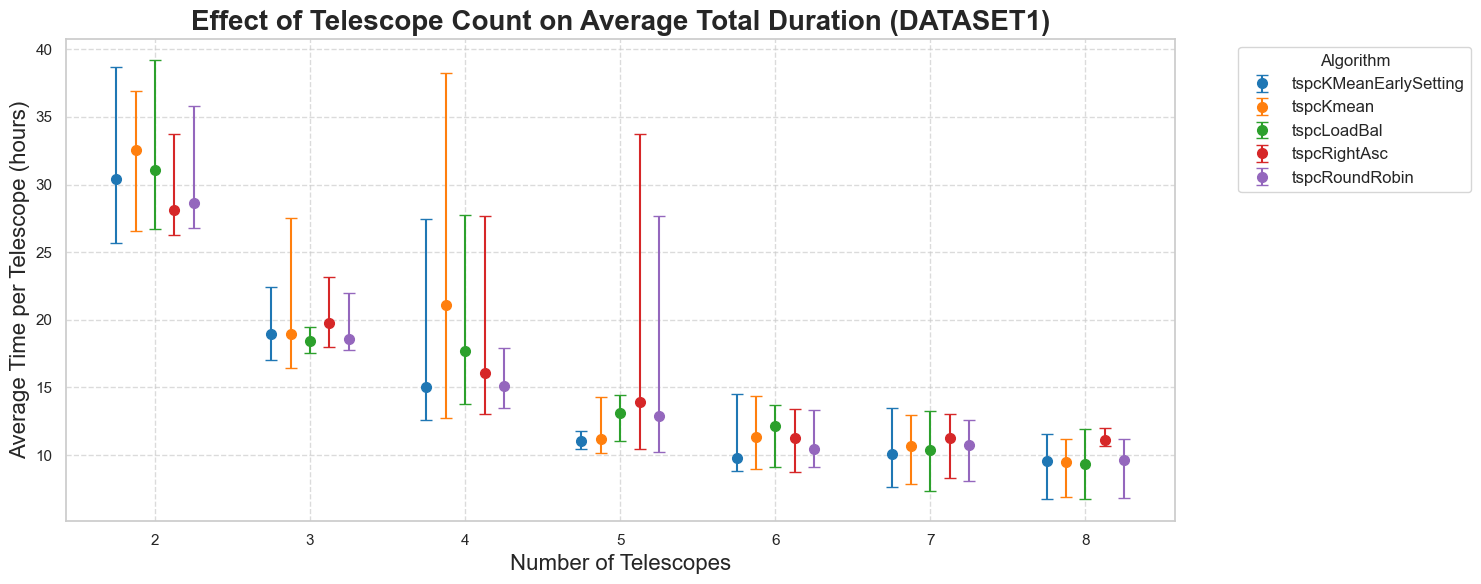

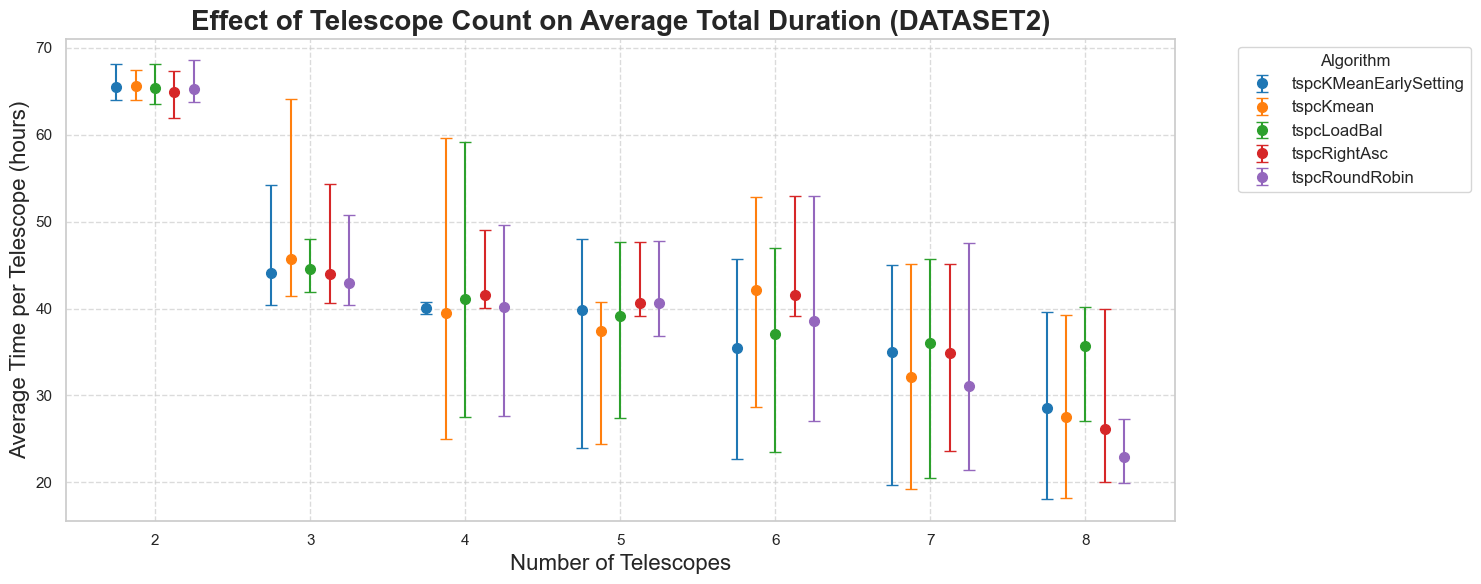

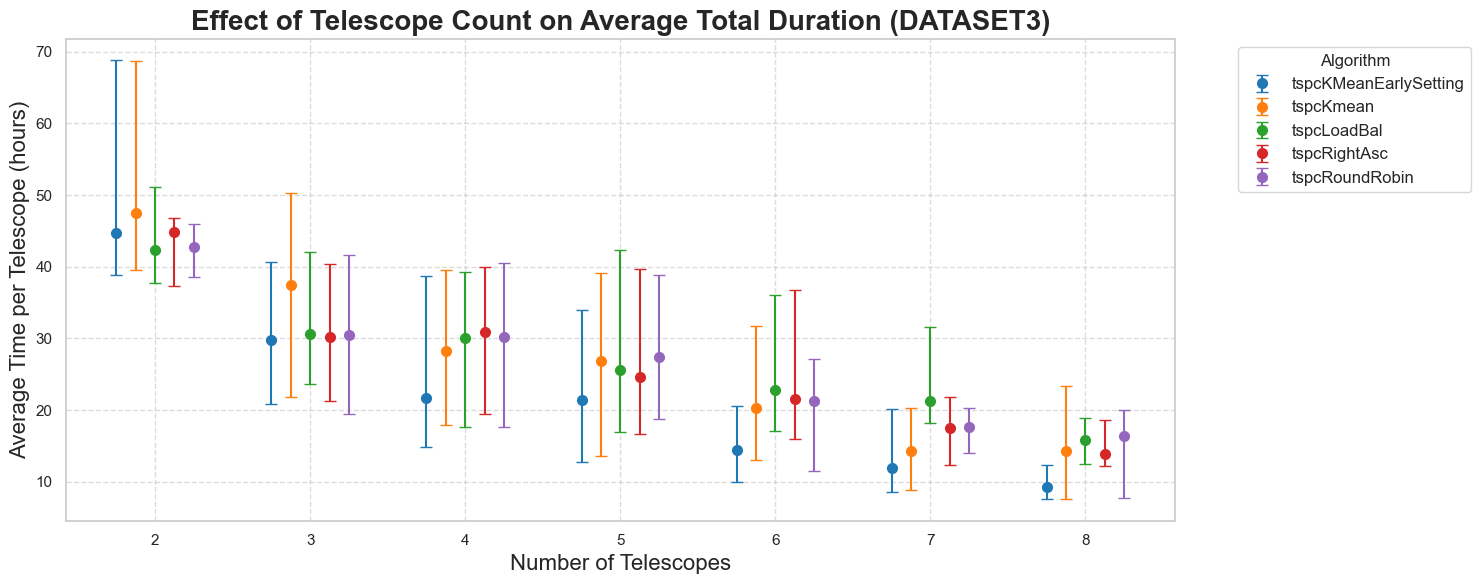

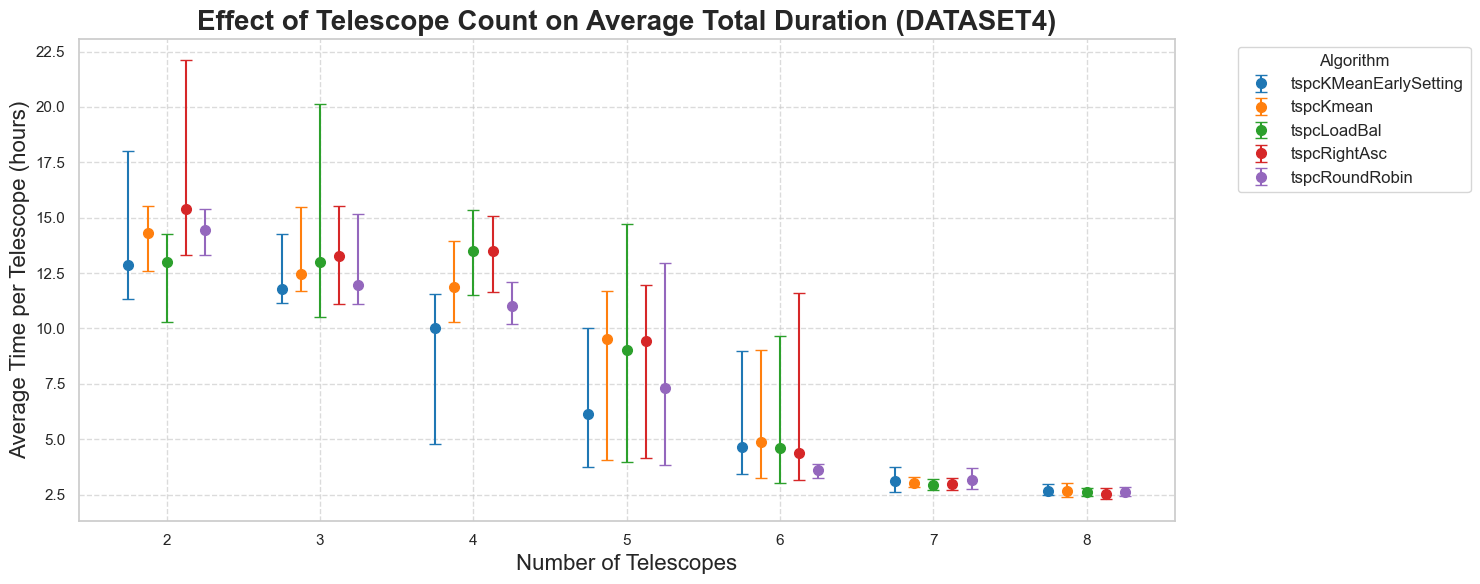

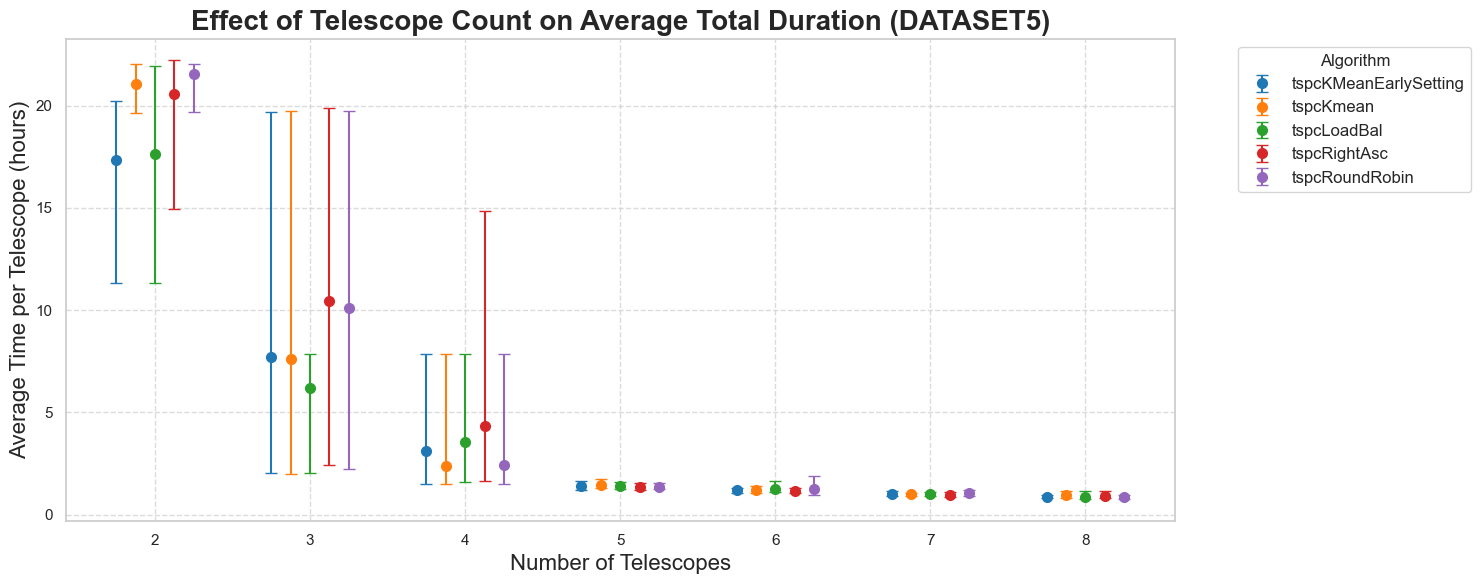

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

# Config
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

# Datasets
datasets = [
    'dataset1/',
    'dataset2/',
    'dataset3/',
    'dataset4/',
    'dataset5/'
]

folder_name_map = {
    "EarliestSetting": "Earliest Setting",
    "Random": "Random",
    "ShortestSlew": "Shortest Slew",
    "tsp": "MTSP Gurobi",
    "tspcRoundRobin": "MTSP Concorde (RRP)",
    "tspcLoadBal": "MTSP Concorde (LBP)",
    "tspcKmean": "MTSP Concorde (KmP)",
    "tspcRightAsc": "MTSP Concorde (RAP)",
    "tspcKMeanEarlySetting": "MTSP Concorde (KmP + ES)"
}

# Automatically detect folders for 2–8 telescopes
all_folders = []
for tele in range(2, 9):
    all_folders += [
        f'tspcRoundRobin{tele}',
        f'tspcLoadBal{tele}',
        f'tspcKmean{tele}',
        f'tspcRightAsc{tele}',
        f'tspcKMeanEarlySetting{tele}'
    ]
folders = all_folders

dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')

    stats_list = []

    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
    
        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")
    
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
    
                # Compute total duration: sum Duration over all telescopes
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                total_duration = df['No'].sum()
    
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                total_observation = df['Wait time'].sum()
    
                tele_count = df['No'].nunique() if 'No' in df.columns else 4

                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Telescopes': tele_count,
                    'Total Duration': total_duration / tele_count,
                    'Observation Time': total_observation / tele_count
                })
    
            except Exception as e:
                print(f"Error processing {file}: {e}")

    
    dataset_df = pd.DataFrame(stats_list)
    dataset_dfs[dataset_name] = dataset_df

for dataset_name, df in dataset_dfs.items():
    if df.empty:
        continue

    # Clean algorithm names (remove telescope number)
    df['Algorithm'] = df['Folder'].apply(lambda f: re.sub(r'\d+$', '', f))

    # Aggregate stats
    grouped = (
        df.groupby(['Algorithm', 'Telescopes'])['Total Duration']
        .agg(['mean', 'min', 'max'])
        .reset_index()
    )

    plt.figure(figsize=(15, 6))

    algorithms = grouped['Algorithm'].unique()
    palette = sns.color_palette("tab10", n_colors=len(algorithms))
    color_map = dict(zip(algorithms, palette))

    telescope_counts = sorted(grouped['Telescopes'].unique())
    num_algos = len(algorithms)

    # Precompute horizontal offsets like your example
    # Spread them evenly around each integer telescope count
    offset_values = np.linspace(-0.25, 0.25, num_algos)

    for i, algo in enumerate(algorithms):
        algo_data = grouped[grouped['Algorithm'] == algo]
        # Compute x-values with fixed offsets
        x = algo_data['Telescopes'] + offset_values[i]
        y = algo_data['mean'].values
        yerr = np.array([
            y - algo_data['min'].values,
            algo_data['max'].values - y
        ])

        plt.errorbar(
            x, y, yerr=yerr,
            fmt='o', capsize=4, markersize=7,
            color=color_map[algo],
            label=algo
        )

    plt.title(f"Effect of Telescope Count on Average Total Duration ({dataset_name.upper()})", fontsize=20, weight='bold')
    plt.xlabel("Number of Telescopes", fontsize=16)
    plt.ylabel("Average Time per Telescope (hours)", fontsize=16)
    plt.xticks(telescope_counts)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()
